Temel olarak görüntüleri sınıflandırmak ve nesne tanıma yapmak için kullanılır. Bir girdi görüntüsünü alıp, görüntüdeki çeşitli görünüşleri/nesneleri birbirinden ayırabilen derin öğrenme ağ çeşididir.

![sinir ağı katmanları](cnn_steps.png)

1) Convulution (Evrişim) Katmanı : Bu katmanda görsellerden özellik çıkarılır. Bir insanın insan yüzünü öğrenirken gözlere ve ağıza odaklanması gibi. Yani giriş görüntüsü üzerinden öznitelik çıkarımı yapılmaktadır.
2) Batch Normalization : Bir sinir ağının gizli katmanları arasında yapılan bir normalleştirme işlemidir. Tüm veriyi değil de mini gruplar halinde normalleştirme işlemi yapılmaktadır. Normalleştirme işlemi mini batch ortalama ve mini batch varyans üzerinden gerçekleştirilmektedir.
3) Aktivasyon Fonksiyonu Katmanı : Karmaşık yapıdaki veriler içerisinden yapay sinir ağlarının öğrenmesini sağlayabilmek adına kullanılan fonksiyonlara aktivasyon fonksiyonları denir.
4) Havuzlama (Pooling) Katmanı : Görüntünün özelleiklerini kaybetmeden boyutunu azaltma katmanıdır. BU katmanda öğrenme olayı yoktur.
5) Tam bağlantı (Fully Connected & Flatten) Katmanı : Verimizi yapay sinir ağının anlayabileceği bir formata getirme adımıdır. Yani burada matris formatındaki veriyi tek boyutlu hale getiriyoruz.
6) Sönümleme (Dropout) Katmanı : Sinir ağı içerisinde yer alan nöronların kullanıcı tarafından belirlenen bir oranda rastgele olarak söndürülmesiyle aşırı öğrenmeyi önleyerek, performansın artırılması amaçlanmaktadır.

![cnn mimarisi](mimari.png)

Şimdi Uçtan uca CNN ile uçtan uca bir örnek yapalım.

# Evrişimli Sinir Ağları ile Katı Atık Tespiti

1. İş problemi
2. Veriyi Anlamak
3. Veriyi Hazırlamak
4. Modelleme
5. Değerlendirme


In [1]:
# Veriyi okuma ve işleme adımında kullanılacak olan kütüphaneler
import cv2
import urllib
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import random, os, glob, math
from imutils import paths
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from urllib.request import urlopen

# Warningsleri kapatmamız için gerekli olan kütüphane
import warnings
warnings.filterwarnings("ignore")

# Model değerlendirme için kullanılacak olan kütüphaneler
from sklearn.metrics import confusion_matrix, classification_report

# Model için kullanılacak olan kütüphaneler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D, Dense, Dropout, SpatialDropout2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img, load_img

2024-10-24 12:24:44.126633: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Veri setinin dosya yolunu kaydedelim.
dir_path = "dataset-resized"

In [4]:
# Target size ve Label etiket değerlerini belirleyelim. Normalde görseller 224x224 değil.
target_size = (224, 224)

waste_labels = {"cardboard" : 0, "glass" : 1, "metal" : 2, "paper" : 3, "plastic" : 4, "trash" : 5} # Klasör isimlerini etiket olarak ayarlıyoruz.

In [5]:
def load_images(path):

    """
    Görsellerin bulunduğu dizindeki görüntüyü okuyup etiketlerini oluşturur.

    Parametreler:
    path : Görsellerin bulunduğu dizini ifade eder.

    Return:
    x: Görüntülere ait matris bilgilerini tutar.
    labels: Görüntünün ait olduğu sınıf bilgisini tutan bir listedir.

    """

    x = []
    labels = []

    #Gönderdiğimiz pathdeki görüntüleri listeleyip sıralayalım.
    image_paths = sorted(list(paths.list_images(path)))

    for image_path in image_paths:

        # Belirtilen pathdeki görüntüleri openCV kütüphanesi ile okuyalım.
        img = cv2.imread(image_path)

        # Okunan görüntüleri başlangıçta belirttiğimiz target_size' a göre yeniden ölçeklendirelim.
        img = cv2.resize(img, target_size)

        # Ölçeklendirilen görüntüleri x listesine ekleyelim.
        x.append(img)

        # Her bir path "/" ifadesi ile ayrıldığında dönen listenin sondan ikinci elemanı labelı temsil etmektedir.
        label = image_path.split(os.path.sep)[-2]

        # Yakalanan labelların sayısal değer karşılıklarının olduğu yukarıda tanımladığımız waste_labels sözlüğü içerisinden
        #gönderilen key değerine karşılık gelen value değeri alınarak label oluşturulur.
        labels.append(waste_labels[label])

    # Veri setini random bir şekilde karıştıralım. Çünkü sıralı olarak düzenledik. Model başarısı için randomize etmek önemli.
    x, labels = shuffle(x, labels, random_state = 42)

    # Boyut ve sınıf bilgisini raporlayalım.
    print(f"x boyutu: {np.array(x).shape}")
    print(f"Label sınıf sayısı: {len(np.unique(labels))} Gözlem sayısı: {len(labels)}")

    return x, labels

In [6]:
x, labels = load_images(dir_path)

x boyutu: (2527, 224, 224, 3)
Label sınıf sayısı: 6 Gözlem sayısı: 2527


In [7]:
# Şimdi de görüntü boyutlarını tutalım
input_shape = (np.array(x[0]).shape[1], np.array(x[0]).shape[1], 3)
input_shape

(224, 224, 3)

In [8]:
len(x)

2527

Veri setinden bazı örnekleri gösterelim.

In [9]:
def visualize_img(image_batch, label_batch):
    """
    Veri seti içerisinden görüntü görselleştir.


    Parametreler:

    image_batch: Görüntülere ait matris bilgilerini tutar.

    label_batch: Görüntülerin ait olduğu sınıf bilgisini tutan listedir.

    """

    plt.figure(figsize = (10, 10))
    for n in range(10):
        ax = plt.subplot(5, 5, n + 1)
        plt.imshow(image_batch[n])
        plt.title(np.array(list(waste_labels.keys()))[to_categorical(labels, num_classes= 6)[n] == 1][0].title())
        plt.axis("off")

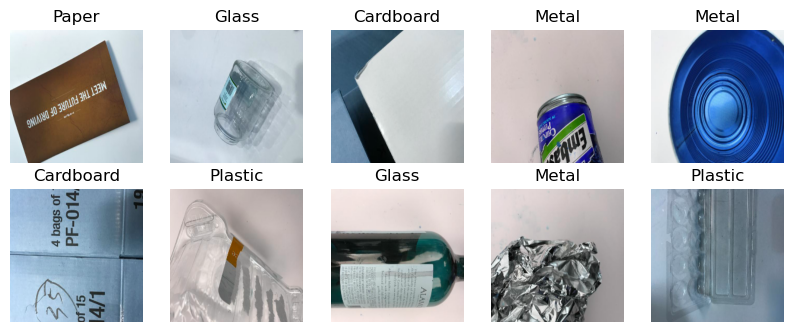

In [10]:
visualize_img(x, labels)

# 3.Veriyi hazırlamak

In [11]:
# Train veri seti için bir generator tanımlayalım.
train = ImageDataGenerator(horizontal_flip = True, vertical_flip = True, validation_split = 0.1, rescale = 1./ 255,
                          shear_range = 0.1, zoom_range = 0.1, width_shift_range = 0.1, height_shift_range = 0.1)

# Test veri seti için de bir generator tanımlayalım.
test = ImageDataGenerator(rescale = 1/ 255, validation_split = 0.1)

In [12]:
# Şimdi bu generatorları kendi veri setimizde uygulayalım ve data augmention adımını tamamlayalım.

train_generator = train.flow_from_directory(directory = dir_path, target_size = (target_size),
                                            class_mode = "categorical", subset = "training")

test_generator = test.flow_from_directory(directory = dir_path, target_size = (target_size), batch_size = 251,
                                          class_mode = "categorical", subset = "validation")

Found 2276 images belonging to 6 classes.
Found 251 images belonging to 6 classes.


# 4. Modelleme
* 4.1 Sequential
* 4.2 Evrişim katmanı (Convulution, Conv2D)
* 4.3 Havuzlama katmanı (pooling layer)
* 4.4 Aktivasyon fonksiyonu katmanı (Activation layer)
* 4.5 Flattening katmanı
* 4.6 Dense katmanı
* 4.7 Dropout katmanı

In [13]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3, 3), padding = "same", input_shape = (input_shape), activation = "relu"))
model.add(MaxPooling2D(pool_size = 2, strides = (2, 2)))

model.add(Conv2D(filters = 64, kernel_size = (3, 3), padding = "same", activation = "relu"))
model.add(MaxPooling2D(pool_size = 2, strides = (2, 2)))

model.add(Conv2D(filters = 32, kernel_size = (3, 3), padding = "same", activation = "relu"))
model.add(MaxPooling2D(pool_size = 2, strides = (2, 2)))

model.add(Flatten())

model.add(Dense(units = 64, activation = "relu"))
model.add(Dropout(rate = 0.2))

model.add(Dense(units = 32, activation = "relu"))
model.add(Dropout(rate = 0.2))

model.add(Dense(units = 6, activation = "softmax"))

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,645,830 (6.28 MB)

 Trainable params: 1,645,830 (6.28 MB)

 Non-trainable params: 0 (0.00 B)

![summary](summary.png)

In [15]:
model.compile(loss = "categorical_crossentropy", optimizer = "adam",
             metrics = [tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), "acc"])

In [16]:
callbacks = [EarlyStopping(monitor = "val_los", patience= 50, verbose= 1, mode= "min"),
            ModelCheckpoint(filepath="mymodel.keras", monitor= "val_loss", mode = "min", save_best_only= True,
                           save_weights_only= False, verbose = 1)]

In [17]:
# Artık modelimizi eğitebiliriz.
history = model.fit(train_generator, epochs=100, validation_data=test_generator,
                    callbacks=callbacks, validation_steps=251 // 32, steps_per_epoch=2276 // 32)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.2011 - loss: 1.8341 - precision: 0.2819 - recall: 0.0120
Epoch 1: val_loss improved from inf to 1.59665, saving model to mymodel.keras


2024-10-24 12:35:35.999901: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


71/71 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - acc: 0.2016 - loss: 1.8329 - precision: 0.2848 - recall: 0.0120 - val_acc: 0.3426 - val_loss: 1.5966 - val_precision: 1.0000 - val_recall: 0.0239
Epoch 2/100
 1/71 ━━━━━━━━━━━━━━━━━━━━ 1:35 1s/step - acc: 0.2500 - loss: 1.5155 - precision: 1.0000 - recall: 0.0938

2024-10-24 12:35:37.645485: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]



Epoch 2: val_loss improved from 1.59665 to 1.57197, saving model to mymodel.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - acc: 0.2500 - loss: 1.5155 - precision: 1.0000 - recall: 0.0938 - val_acc: 0.3745 - val_loss: 1.5720 - val_precision: 1.0000 - val_recall: 0.0558
Epoch 3/100


...

2024-10-24 14:20:33.014369: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


 1/71 ━━━━━━━━━━━━━━━━━━━━ 1:52 2s/step - acc: 0.8125 - loss: 0.5665 - precision: 0.9231 - recall: 0.7500

2024-10-24 14:20:34.657331: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]



Epoch 100: val_loss did not improve from 0.80189
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - acc: 0.8125 - loss: 0.5665 - precision: 0.9231 - recall: 0.7500 - val_acc: 0.6773 - val_loss: 0.9151 - val_precision: 0.8111 - val_recall: 0.5817


2024-10-24 14:20:39.213665: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


Accuracy ve loss değerlerini görselleştirelim.

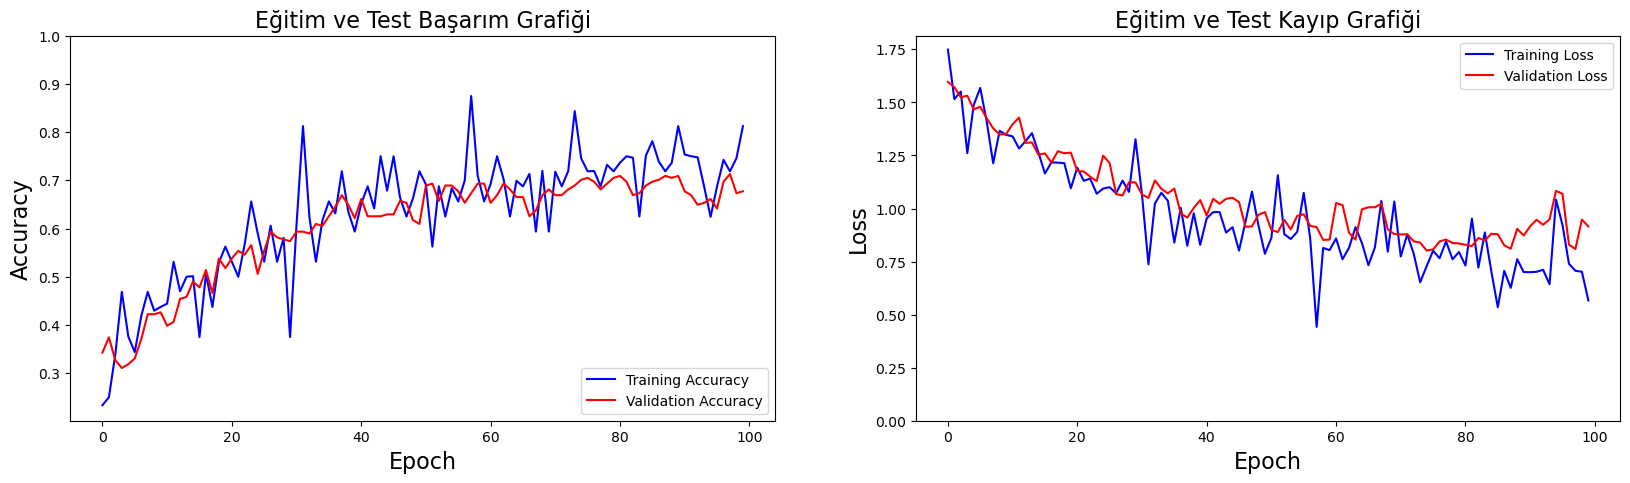

In [19]:
# Grafik 1: Accuracy
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["acc"], color = "b", label = "Training Accuracy")
plt.plot(history.history["val_acc"], color = "r", label = "Validation Accuracy")
plt.legend(loc = "lower right")

plt.xlabel("Epoch", fontsize = 16)
plt.ylabel("Accuracy", fontsize = 16)
plt.ylim([min(plt.ylim()), 1])
plt.title("Eğitim ve Test Başarım Grafiği", fontsize = 16)



# Grafik 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], color = "b", label = "Training Loss")
plt.plot(history.history["val_loss"], color = "r", label = "Validation Loss")
plt.legend(loc = "upper right")

plt.xlabel("Epoch", fontsize = 16)
plt.ylabel("Loss", fontsize = 16)
plt.ylim([0, max(plt.ylim())])
plt.title("Eğitim ve Test Kayıp Grafiği", fontsize = 16)
plt.show()

# 5. Değerlendirme

In [20]:
loss, precision, recall, acc = model.evaluate(test_generator, batch_size= 32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - acc: 0.6773 - loss: 0.9151 - precision: 0.8111 - recall: 0.5817


In [21]:
print("\nTest accuracy: %.1f%%" % (100.0 * acc))
print("\nTest loss: %.1f%%" % (100.0 * loss))
print("\nTest precision: %.1f%%" % (100.0 * precision))
print("\nTest recall: %.1f%%" % (100.0 * recall))


Test accuracy: 67.7%

Test loss: 91.5%

Test precision: 81.1%

Test recall: 58.2%


In [24]:
# Classification report
x_test, y_test = next(iter(test_generator))

y_pred = model.predict(x_test)

y_pred = np.argmax(y_pred, axis=1)
y_test = np.argmax(y_test, axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 462ms/step


In [25]:
target_names = list(waste_labels.keys())

In [26]:
print(classification_report(y_test, y_pred, target_names= target_names))

              precision    recall  f1-score   support

   cardboard       0.73      0.68      0.70        40
       glass       0.67      0.70      0.69        50
       metal       0.52      0.80      0.63        41
       paper       0.89      0.93      0.91        59
     plastic       0.71      0.21      0.32        48
       trash       0.45      0.77      0.57        13

    accuracy                           0.68       251
   macro avg       0.66      0.68      0.64       251
weighted avg       0.70      0.68      0.66       251



In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label', fontweight="bold")
    plt.xlabel('Predicted label', fontweight="bold")


# Modelin kullanılması / Test edilmesi

In [30]:
waste_labels = {0: "cardboard", 1: "glass", 2: "metal", 3: "paper", 4: "plastic", 5: "trash"}

In [31]:
def model_testing(path):

  """
  Görsellerin bulunduğu dizindeki görüntüyü okuyup model aracılığıyla hangi sınıfa ait olduğuna dair
  tahmin işlemi gerçekleştirir.

  Parametreler:
  path: Görsellerin bulunduğu dosya yolu(dizin)dur.

  Return:
  img: Görüntü

  p: Tahmin olasılıkları

  predicted_class: Tahmin sınıfı

  """
  img = image.load_img(path, target_size = (target_size))
  img = image.img_to_array(img, dtype = np.uint8)
  img = np.array(img) /255.0
  p = model.predict(img.reshape(1, 224, 224, 3))
  predicted_class = np.argmax(p[0])

  return img, p, predicted_class

In [33]:
img1, p1, predicted_class1 = model_testing("dataset-resized/metal/metal10.jpg")
img2, p2, predicted_class2 = model_testing("dataset-resized/glass/glass143.jpg")
img3, p3, predicted_class3 = model_testing("dataset-resized/trash/trash101.jpg")
img4, p4, predicted_class4 = model_testing("dataset-resized/paper/paper291.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


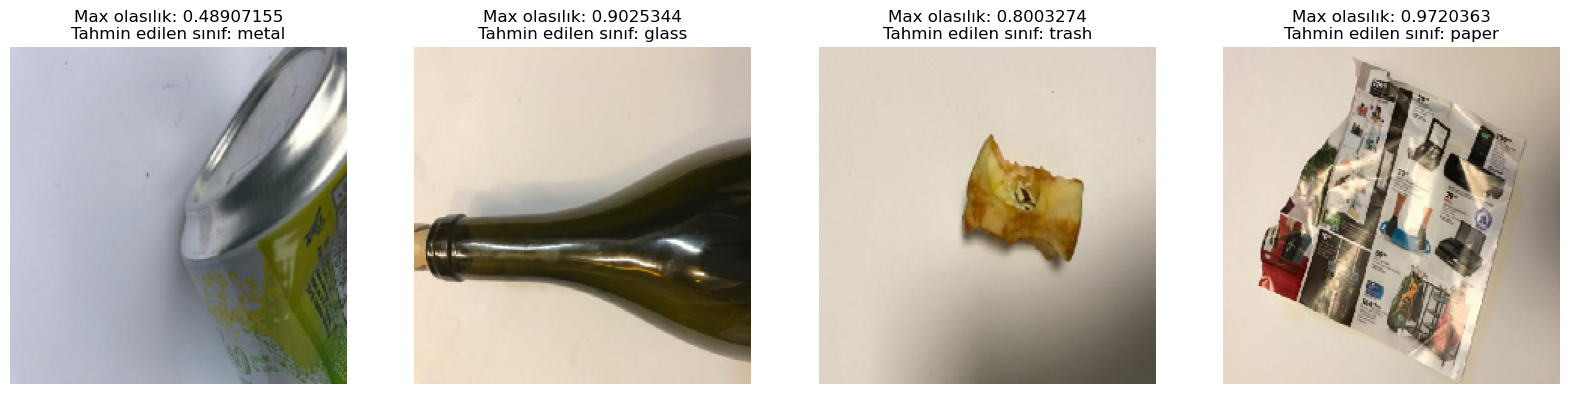

In [34]:
plt.figure(figsize = (20, 60))

plt.subplot(141)
plt.axis("off")
plt.imshow(img1.squeeze())
plt.title("Max olasılık: " + str(np.max(p1[0], axis = -1)) + "\n" +
          "Tahmin edilen sınıf: " + str(waste_labels[predicted_class1]))
plt.imshow(img1)


plt.subplot(142)
plt.axis("off")
plt.imshow(img2.squeeze())
plt.title("Max olasılık: " + str(np.max(p2[0], axis = -1)) + "\n" +
          "Tahmin edilen sınıf: " + str(waste_labels[predicted_class2]))
plt.imshow(img2)


plt.subplot(143)
plt.axis("off")
plt.imshow(img3.squeeze())
plt.title("Max olasılık: " + str(np.max(p3[0], axis = -1)) + "\n" +
          "Tahmin edilen sınıf: " + str(waste_labels[predicted_class3]))
plt.imshow(img3)


plt.subplot(144)
plt.axis("off")
plt.imshow(img4.squeeze())
plt.title("Max olasılık: " + str(np.max(p4[0], axis = -1)) + "\n" +
          "Tahmin edilen sınıf: " + str(waste_labels[predicted_class4]))
plt.imshow(img4)

In [47]:
img5, p5, predicted_class5 = model_testing("paper.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


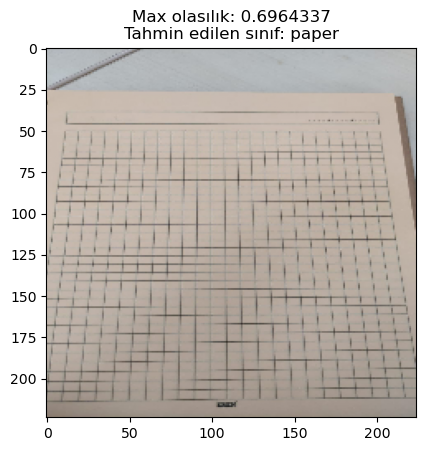

In [49]:
plt.imshow(img5.squeeze())
plt.title("Max olasılık: " + str(np.max(p5[0], axis = -1)) + "\n" +
          "Tahmin edilen sınıf: " + str(waste_labels[predicted_class5]))
plt.imshow(img5)